# Stress Detection in Social Media: Dreaddit Analysis
## Individual Assignment 2 — AI for Mental Health

---

## Approach Overview

This notebook compares **three modelling approaches** of increasing sophistication:

| Track | Model | Features |
|-------|-------|----------|
| 1 | Gradient Boosting | 109 psycholinguistic (LIWC, DAL, social) |
| 2 | Fine-tuned BERT | Raw text (contextual embeddings) |
| 3 | Ensemble | BERT logits + LIWC features |

We then conduct **three deep-dive analyses** and conclude with **deployment considerations for Singapore's mental health context**.

---


## 1. Setup

We use standard data science libraries plus HuggingFace `transformers` for BERT.

**Install if needed:**
```bash
pip install transformers torch scikit-learn pandas numpy matplotlib seaborn
```


In [77]:
# ── Core libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, random
warnings.filterwarnings('ignore')

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (classification_report, f1_score,
                              roc_auc_score, roc_curve)

# ── PyTorch & HuggingFace ────────────────────────────────────────────────────
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print("\nAll libraries loaded!")


Device: cpu
GPU available: False

All libraries loaded!


## 2. Data Loading & EDA

The Dreaddit dataset contains Reddit posts from 10 mental health-related communities. Each post is labelled **1 (stressed)** or **0 (non-stressed)** by human annotators, with a confidence score. Pre-computed features include LIWC (Linguistic Inquiry and Word Count), DAL (Dictionary of Affect in Language), social metadata, and readability scores.

**Important:** Your teacher provided pre-split train and test files. We load both separately to ensure everyone evaluates on the same test set.


In [78]:
from pathlib import Path

BASE_DIR = Path.cwd()
train_df = pd.read_csv(BASE_DIR / "data" / "dreaddit-train.csv")
test_df  = pd.read_csv(BASE_DIR / "data" / "dreaddit-test.csv")

# Combine for EDA purposes only
df = pd.concat([train_df, test_df], ignore_index=True)

# Fill numeric NaNs with column median
for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(df[col].median(), inplace=True)

df['text_len'] = df['text'].str.split().str.len()

# ── Report actual counts, not assumed counts ──────────────────────────────────
n_stressed     = int((df['label'] == 1).sum())
n_nonstressed  = int((df['label'] == 0).sum())
balance_pct    = n_stressed / len(df) * 100

print(f"Combined dataset shape: {df.shape}")
print(f"Training set: {len(train_df)} samples")
print(f"Test set: {len(test_df)} samples")
print(f"Labels — Stressed: {n_stressed} ({balance_pct:.1f}%)  |  Non-Stressed: {n_nonstressed} ({100-balance_pct:.1f}%)")
print(f"Subreddits: {df['subreddit'].nunique()} communities")
print(f"Text length — mean: {df['text_len'].mean():.0f} words, max: {df['text_len'].max()} words")
print(f"Posts > 512 tokens: {(df['text_len'] > 512).sum()}   (safe for BERT!)")
df.head(3)


Combined dataset shape: (3553, 117)
Training set: 2838 samples
Test set: 715 samples
Labels — Stressed: 1857 (52.3%)  |  Non-Stressed: 1696 (47.7%)
Subreddits: 10 communities
Text length — mean: 86 words, max: 310 words
Posts > 512 tokens: 0   (safe for BERT!)


,subreddit,post_id,sentence_range,text,id,label,confidence,social_timestamp,social_karma,syntax_ari,...,lex_dal_min_activation,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness,social_upvote_ratio,social_num_comments,syntax_fk_grade,sentiment,text_len
0,ptsd,8601tu,"(15, 20)","He said he had not felt that way before, sugge...",33181,1,0.8,1.521614e+09,5,1.806818,...,1.1250,1.0,1.77000,1.52211,1.89556,0.86,1,3.253573,-0.002742,113
1,assistance,8lbrx9,"(0, 5)","Hey there r/assistance, Not sure if this is th...",2606,0,1.0,1.527010e+09,4,9.429737,...,1.0000,1.0,1.69586,1.62045,1.88919,0.65,2,8.828316,0.292857,108
2,ptsd,9ch1zh,"(15, 20)",My mom then hit me with the newspaper and it s...,38816,1,0.8,1.535936e+09,2,7.769821,...,1.1429,1.0,1.83088,1.58108,1.85828,0.67,0,7.841667,0.011894,166


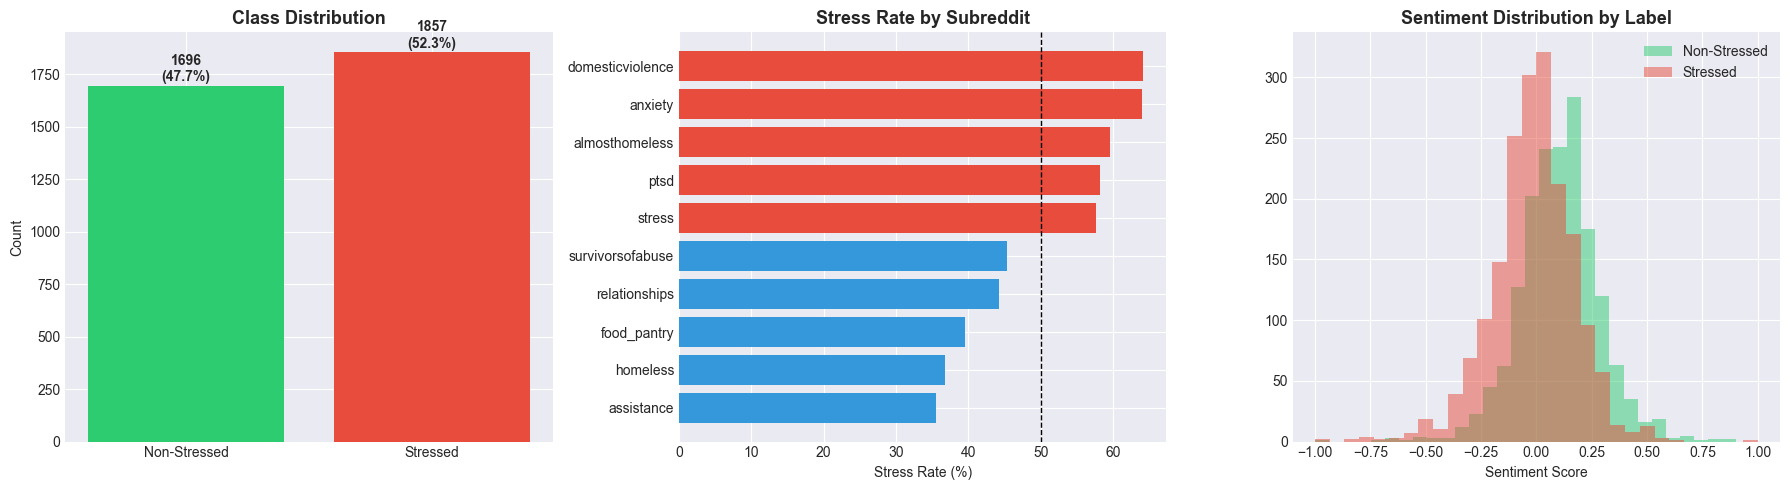

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: Class distribution ──────────────────────────────────────────────
counts = df['label'].value_counts().sort_index()
axes[0].bar(['Non-Stressed', 'Stressed'], counts.values, color=['#2ecc71', '#e74c3c'])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Class Distribution', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Count')

# ── Panel 2: Stress rate per subreddit ───────────────────────────────────────
stress_rate = df.groupby('subreddit')['label'].mean().sort_values()
colors = ['#e74c3c' if x > 0.5 else '#3498db' for x in stress_rate.values]
axes[1].barh(stress_rate.index, stress_rate.values * 100, color=colors)
axes[1].axvline(50, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Stress Rate (%)')
axes[1].set_title('Stress Rate by Subreddit', fontweight='bold', fontsize=13)

# ── Panel 3: Sentiment vs Stress ─────────────────────────────────────────────
for label, color, name in [(0, '#2ecc71', 'Non-Stressed'), (1, '#e74c3c', 'Stressed')]:
    axes[2].hist(df[df['label'] == label]['sentiment'], bins=30,
                 alpha=0.5, color=color, label=name)
axes[2].set_xlabel('Sentiment Score')
axes[2].set_title('Sentiment Distribution by Label', fontweight='bold', fontsize=13)
axes[2].legend()

plt.tight_layout()
plt.show()


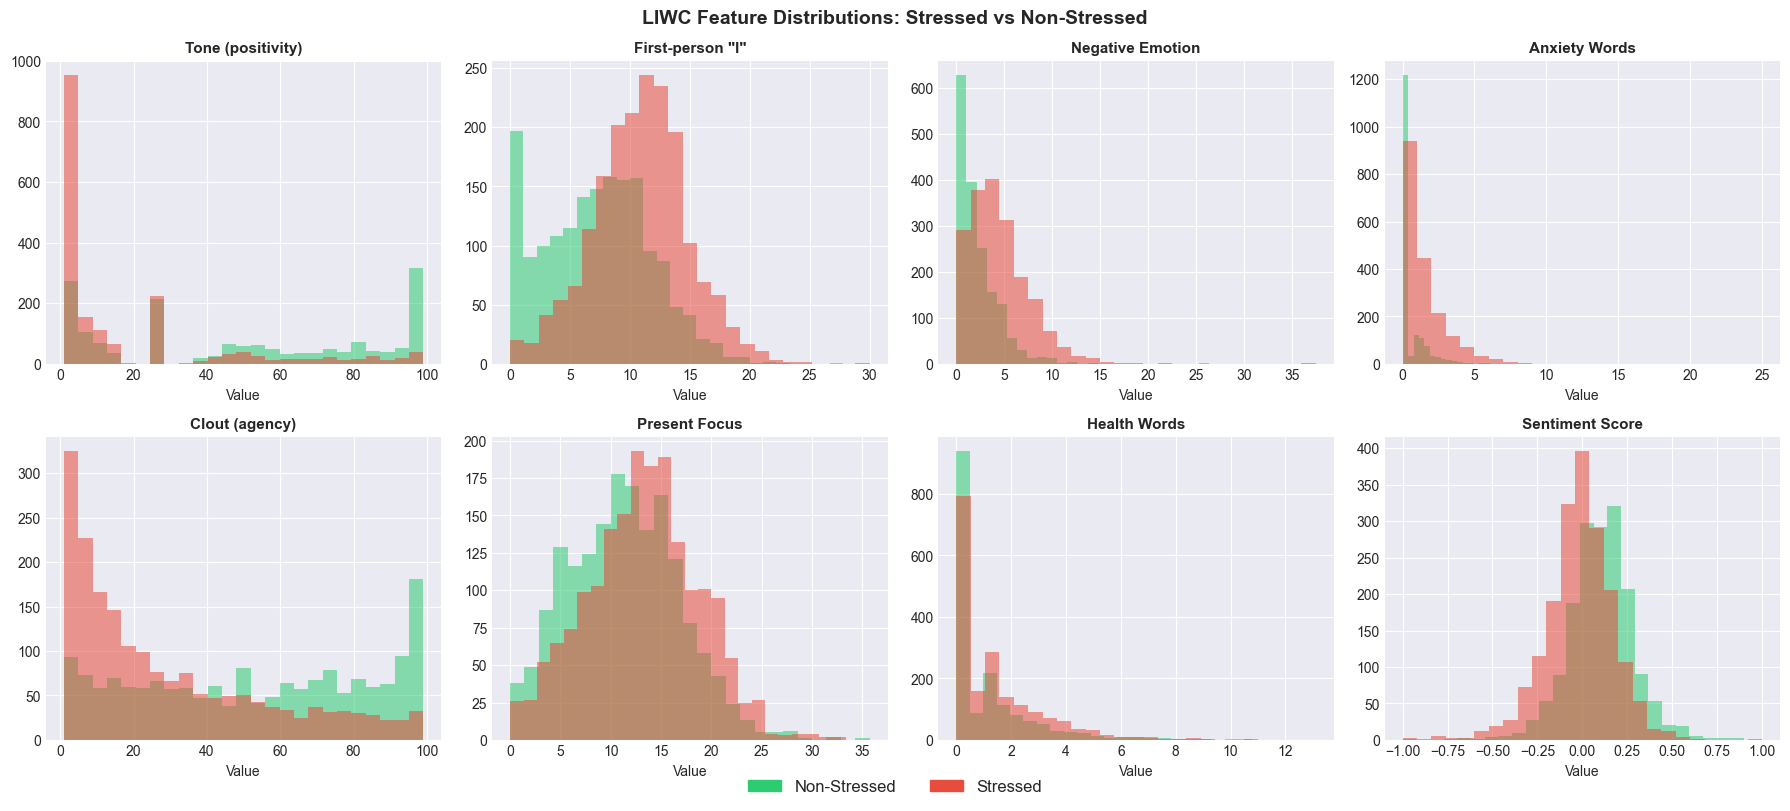

In [80]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

features_to_plot = [
    ('lex_liwc_Tone',         'Tone (positivity)'),
    ('lex_liwc_i',            'First-person "I"'),
    ('lex_liwc_negemo',       'Negative Emotion'),
    ('lex_liwc_anx',          'Anxiety Words'),
    ('lex_liwc_Clout',        'Clout (agency)'),
    ('lex_liwc_focuspresent', 'Present Focus'),
    ('lex_liwc_health',       'Health Words'),
    ('sentiment',             'Sentiment Score'),
]

for ax, (feat, title) in zip(axes, features_to_plot):
    for label, color, name in [(0, '#2ecc71', 'Non-Stressed'), (1, '#e74c3c', 'Stressed')]:
        ax.hist(df[df['label'] == label][feat], bins=25, alpha=0.55, color=color, label=name)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')

handles = [mpatches.Patch(color='#2ecc71', label='Non-Stressed'),
           mpatches.Patch(color='#e74c3c', label='Stressed')]
fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=12, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('LIWC Feature Distributions: Stressed vs Non-Stressed', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**EDA takeaways:**
- The dataset is **nearly balanced** (1696 stressed / 1857 non-stressed).
- **Tone and Clout** show the clearest separation.
- **"I" pronouns and anxiety words** are higher in stressed posts.

## 3. Prepare Train / Validation / Test Sets

**Data splits:**
1. **Test set**: Final evaluation only — never touched during training or hyperparameter tuning.
2. **Training set**: Further split into:
   - **Train subset (80%)**: For model training.
   - **Validation set (20%)**: For monitoring during training and hyperparameter tuning.

This 3-way split ensures no test leakage at any stage.


In [81]:
# Apply same preprocessing to both train and test
for df_split in [train_df, test_df]:
    for col in df_split.select_dtypes(include=[np.number]).columns:
        if df_split[col].isnull().any():
            df_split[col].fillna(df_split[col].median(), inplace=True)

# Create train/validation split from training file
print("Creating train/validation split from training set...")
train_sub, val_sub = train_test_split(
    train_df,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df['label']
)

train_sub = train_sub.reset_index(drop=True)
val_sub   = val_sub.reset_index(drop=True)
test_df   = test_df.reset_index(drop=True)

print(f"\nData splits:")
print(f"  Training subset: {len(train_sub)} samples ({len(train_sub)/len(train_df)*100:.1f}% of original train)")
print(f"  Validation set:  {len(val_sub)} samples ({len(val_sub)/len(train_df)*100:.1f}% of original train)")
print(f"  Test set:        {len(test_df)} samples")

print(f"\nStress rates:")
print(f"  Train subset: {train_sub['label'].mean():.3f}")
print(f"  Validation:   {val_sub['label'].mean():.3f}")
print(f"  Test:         {test_df['label'].mean():.3f}")

y_train = train_sub['label'].values
y_val   = val_sub['label'].values
y_test  = test_df['label'].values


Creating train/validation split from training set...

Data splits:
  Training subset: 2270 samples (80.0% of original train)
  Validation set:  568 samples (20.0% of original train)
  Test set:        715 samples

Stress rates:
  Train subset: 0.524
  Validation:   0.525
  Test:         0.516


## 4. Track 1: Gradient Boosting on Psycholinguistic Features

### Why this model?

Gradient Boosting is an **ensemble of decision trees** trained sequentially where each tree corrects the errors of the previous one. I chose this model because stress is unlikely to be a simple linear combination of features.

1. **Non-linear relationships:** Stress does not depend on individual features in isolation. A combination of features may signal something different than the features alone and tree based model are good at capturing these kind of interactions .
2. **Feature importance:** The model provides a ranking of which psycholinguistic features contribute most to predictions. 
3. **Robustness:** Gradient boosting can handle correlated features as LIWC categories often overlaps without needing feature selection.
4. **Interpretability:** Compared to neural networks, tree-based model are easier to explain, which is important if used in a mental health setting.

In [82]:
# ── Feature sets ─────────────────────────────────────────────────────────────
liwc_feats   = [c for c in df.columns if 'lex_liwc' in c]
dal_feats    = [c for c in df.columns if 'lex_dal'  in c]
social_feats = [c for c in ['social_timestamp', 'social_karma',
                             'social_upvote_ratio', 'social_num_comments'] if c in df.columns]
syntax_feats = [c for c in ['syntax_ari', 'syntax_fk_grade'] if c in df.columns]
all_psycho   = liwc_feats + dal_feats + social_feats + syntax_feats + ['sentiment']

print(f"Total psycholinguistic features: {len(all_psycho)}")
print(f"  LIWC: {len(liwc_feats)}  |  DAL: {len(dal_feats)}  |  Social: {len(social_feats)}  |  Syntax: {len(syntax_feats)}")


Total psycholinguistic features: 109
  LIWC: 93  |  DAL: 9  |  Social: 4  |  Syntax: 2


In [83]:
# ── Prepare feature matrices ─────────────────────────────────────────────────
# Note: No StandardScaler — tree-based models are invariant to monotone
#       feature transformations, so scaling provides no benefit.
X_train_psycho = train_sub[all_psycho].values
X_val_psycho   = val_sub[all_psycho].values
X_test_psycho  = test_df[all_psycho].values

# ── Train Gradient Boosting ───────────────────────────────────────────────────
gb_model = GradientBoostingClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, random_state=SEED
)
print("Training Gradient Boosting model...")
gb_model.fit(X_train_psycho, y_train)

# ── Evaluate on validation set ───────────────────────────────────────────────
gb_val_pred  = gb_model.predict(X_val_psycho)
gb_val_proba = gb_model.predict_proba(X_val_psycho)[:, 1]
val_f1  = f1_score(y_val, gb_val_pred)
val_auc = roc_auc_score(y_val, gb_val_proba)

print(f"\nValidation Performance:")
print(f"F1-Score : {val_f1:.4f}")
print(f"AUC-ROC  : {val_auc:.4f}")

# ── Final evaluation on test set ─────────────────────────────────────────────
gb_pred  = gb_model.predict(X_test_psycho)
gb_proba = gb_model.predict_proba(X_test_psycho)[:, 1]

gb_f1  = f1_score(y_test, gb_pred)
gb_auc = roc_auc_score(y_test, gb_proba)

print("=" * 55)
print("TRACK 1 — Gradient Boosting (Psycholinguistic)")
print("=" * 55)
print(f"Test F1-Score : {gb_f1:.4f}")
print(f"Test AUC-ROC  : {gb_auc:.4f}")
print()
print(classification_report(y_test, gb_pred, target_names=['Non-Stressed', 'Stressed']))


Training Gradient Boosting model...

Validation Performance:
F1-Score : 0.7664
AUC-ROC  : 0.8498
TRACK 1 — Gradient Boosting (Psycholinguistic)
Test F1-Score : 0.7700
Test AUC-ROC  : 0.8312

              precision    recall  f1-score   support

Non-Stressed       0.77      0.69      0.73       346
    Stressed       0.74      0.81      0.77       369

    accuracy                           0.75       715
   macro avg       0.75      0.75      0.75       715
weighted avg       0.75      0.75      0.75       715



## 5. Track 2: Fine-tuned BERT

### Why BERT?

BERT (**B**idirectional **E**ncoder **R**epresentations from **T**ransformers) was pre-trained on billions of words and learns **contextual meaning** as the same word means different things in different sentences.

We use `bert-base-uncased` — 12 transformer layers, 110M parameters, pre-trained on Wikipedia + BookCorpus. We **fine-tune** it by adjusting the pre-trained weights on our labelled Dreaddit data.

In [84]:
class DreadditDataset(Dataset):
    """
    Wraps Reddit text + labels into a PyTorch Dataset.
    The tokenizer converts raw text → input_ids + attention_mask,
    which are the two tensors BERT needs.
    """
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

print("Dataset class defined.")


Dataset class defined.


In [85]:
MODEL_NAME = 'bert-base-uncased'

tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)
bert_model = bert_model.to(DEVICE)

BATCH_SIZE = 16  # Increase to 32 on GPU

train_dataset = DreadditDataset(train_sub['text'].values, y_train, tokenizer)
val_dataset   = DreadditDataset(val_sub['text'].values,   y_val,   tokenizer)
test_dataset  = DreadditDataset(test_df['text'].values,   y_test,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}  |  Test batches: {len(test_loader)}")
print(f"Total BERT parameters: {sum(p.numel() for p in bert_model.parameters()):,}")


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1840.41it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those p

Train batches: 142  |  Val batches: 36  |  Test batches: 45
Total BERT parameters: 109,483,778


In [90]:
EPOCHS       = 1
WARMUP_STEPS = int(0.1 * len(train_loader) * EPOCHS)
TOTAL_STEPS  = len(train_loader) * EPOCHS

optimizer = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=TOTAL_STEPS
)

print(f"Training configuration:")
print(f"  Epochs: {EPOCHS}")
print(f"  Total training steps: {TOTAL_STEPS}")
print(f"  Warmup steps: {WARMUP_STEPS}")
print(f"  Estimated time on CPU: ~{15*EPOCHS}-{20*EPOCHS} minutes")


Training configuration:
  Epochs: 1
  Total training steps: 142
  Warmup steps: 14
  Estimated time on CPU: ~15-20 minutes


In [91]:
print("Starting BERT fine-tuning...")
print(f"Training on {len(train_loader)} batches\n")

# ── Training phase ────────────────────────────────────────────────────────────
bert_model.train()
epoch_loss = 0

for batch_idx, batch in enumerate(train_loader):
    input_ids      = batch['input_ids'].to(DEVICE)
    attention_mask = batch['attention_mask'].to(DEVICE)
    labels         = batch['label'].to(DEVICE)

    optimizer.zero_grad()
    outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
    loss = outputs.loss
    loss.backward()
    torch.nn.utils.clip_grad_norm_(bert_model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    epoch_loss += loss.item()

    if (batch_idx + 1) % 50 == 0 or (batch_idx + 1) == len(train_loader):
        print(f"  Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

avg_loss = epoch_loss / len(train_loader)
print(f"\nTraining Loss: {avg_loss:.4f}")

# ── Validation phase ──────────────────────────────────────────────────────────
bert_model.eval()
all_preds = []

with torch.no_grad():
    for batch in val_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        outputs        = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        preds          = outputs.logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)

val_f1 = f1_score(y_val, all_preds)
print(f"Validation F1: {val_f1:.4f}")


# ── Final evaluation on test set ─────────────────────────────────────────────
print("Evaluating on test set...")
test_preds, test_probas = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        outputs        = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        probas = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
        preds  = outputs.logits.argmax(dim=1).cpu().numpy()
        test_preds.extend(preds)
        test_probas.extend(probas)

bert_pred  = np.array(test_preds)
bert_proba = np.array(test_probas)

bert_f1  = f1_score(y_test, bert_pred)
bert_auc = roc_auc_score(y_test, bert_proba)

print("=" * 55)
print("TRACK 2 — Fine-tuned BERT")
print("=" * 55)
print(f"Test F1-Score : {bert_f1:.4f}")
print(f"Test AUC-ROC  : {bert_auc:.4f}")
print()
print(classification_report(y_test, bert_pred, target_names=['Non-Stressed', 'Stressed']))

Starting BERT fine-tuning...
Training on 142 batches

  Batch 50/142 | Loss: 0.4613
  Batch 100/142 | Loss: 0.4495
  Batch 142/142 | Loss: 0.2854

Training Loss: 0.3622
Validation F1: 0.8553


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.39s/it]


Model saved!
Evaluating on test set...
TRACK 2 — Fine-tuned BERT
Test F1-Score : 0.8181
Test AUC-ROC  : 0.8864

              precision    recall  f1-score   support

Non-Stressed       0.82      0.78      0.80       346
    Stressed       0.80      0.83      0.82       369

    accuracy                           0.81       715
   macro avg       0.81      0.81      0.81       715
weighted avg       0.81      0.81      0.81       715



In [92]:
import os
os.makedirs('bert_stress_model', exist_ok=True)
bert_model.save_pretrained('bert_stress_model')
tokenizer.save_pretrained('bert_stress_model')
print("Model saved!")

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.09s/it]

Model saved!


## 6. Track 3: Ensemble = BERT + GBT

### Why combine them?

BERT understands language context, while Gradient Boosting picks up on psychological word patterns from LIWC. Since they make mistakes in different places, blending their probability scores gives a stronger overall model.

The blending weight α is tuned on the **validation set only**.


In [93]:
# ── Get BERT validation probabilities (using best-checkpoint model) ──────────
bert_model.eval()
bert_val_probas = []
with torch.no_grad():
    for batch in val_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        outputs        = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        probas = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
        bert_val_probas.extend(probas)
bert_val_proba = np.array(bert_val_probas)

# GBT validation probabilities
gb_val_proba = gb_model.predict_proba(X_val_psycho)[:, 1]

# ── Tune alpha on validation set ─────────────────────────────────────────────
print("=" * 55)
print("TRACK 3 — Ensemble (Alpha Tuning on Validation)")
print("=" * 55)

best_alpha, best_f1 = 0, 0
alpha_results = []

print("\nTuning ensemble weight on validation set:")
for alpha in np.round(np.arange(0.0, 1.05, 0.1), 1):
    blended      = alpha * bert_val_proba + (1 - alpha) * gb_val_proba
    blended_pred = (blended >= 0.5).astype(int)
    f1 = f1_score(y_val, blended_pred)
    alpha_results.append({'alpha': alpha, 'f1': f1})
    print(f"  α={alpha:.1f}  →  Val F1={f1:.4f}")
    if f1 > best_f1:
        best_f1, best_alpha = f1, alpha

print(f"\nBest α={best_alpha:.1f} with Validation F1={best_f1:.4f}")

# ── Apply best alpha to test set ─────────────────────────────────────────────
ensemble_proba = best_alpha * bert_proba + (1 - best_alpha) * gb_proba
ensemble_pred  = (ensemble_proba >= 0.5).astype(int)
ensemble_f1    = f1_score(y_test, ensemble_pred)
ensemble_auc   = roc_auc_score(y_test, ensemble_proba)

print("\n" + "=" * 55)
print(f"ENSEMBLE FINAL TEST RESULTS (α={best_alpha:.1f})")
print("=" * 55)
print(f"Test F1-Score: {ensemble_f1:.4f}")
print(f"Test AUC-ROC : {ensemble_auc:.4f}")
print()
print(classification_report(y_test, ensemble_pred, target_names=['Non-Stressed', 'Stressed']))


TRACK 3 — Ensemble (Alpha Tuning on Validation)

Tuning ensemble weight on validation set:
  α=0.0  →  Val F1=0.7664
  α=0.1  →  Val F1=0.7816
  α=0.2  →  Val F1=0.7816
  α=0.3  →  Val F1=0.7947
  α=0.4  →  Val F1=0.8214
  α=0.5  →  Val F1=0.8543
  α=0.6  →  Val F1=0.8633
  α=0.7  →  Val F1=0.8539
  α=0.8  →  Val F1=0.8557
  α=0.9  →  Val F1=0.8553
  α=1.0  →  Val F1=0.8553

Best α=0.6 with Validation F1=0.8633

ENSEMBLE FINAL TEST RESULTS (α=0.6)
Test F1-Score: 0.8136
Test AUC-ROC : 0.8844

              precision    recall  f1-score   support

Non-Stressed       0.82      0.76      0.79       346
    Stressed       0.79      0.84      0.81       369

    accuracy                           0.80       715
   macro avg       0.80      0.80      0.80       715
weighted avg       0.80      0.80      0.80       715



## 7. Model Comparison

All three models evaluated on the same held-out test set.


                   Model       F1      AUC
Gradient Boosting (LIWC) 0.770026 0.831203
         Fine-tuned BERT 0.818061 0.886383
       Ensemble (α=0.60) 0.813648 0.884401


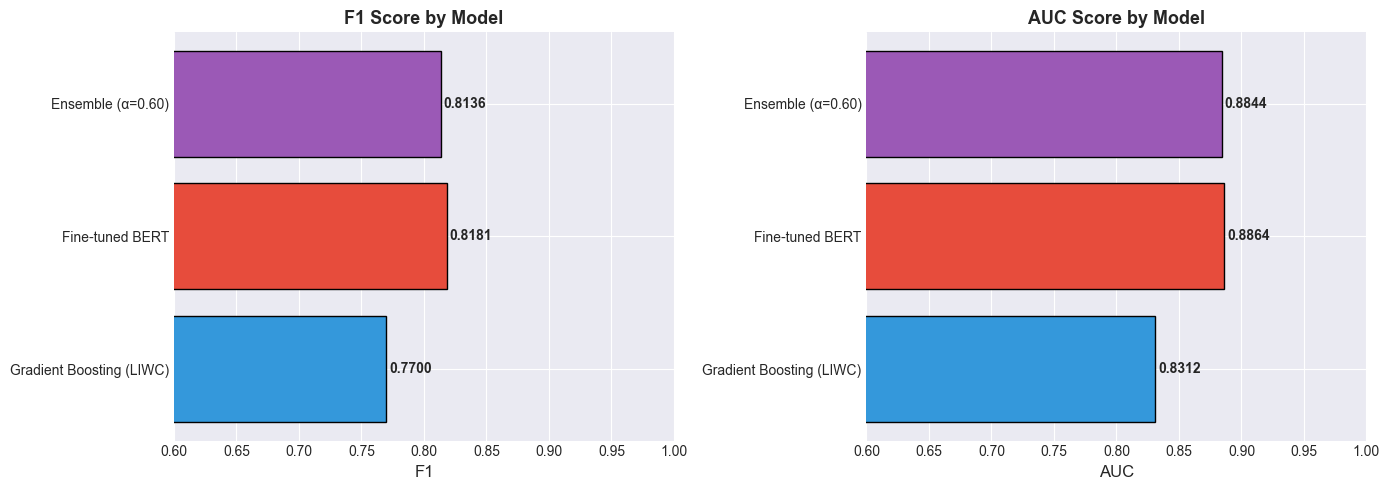

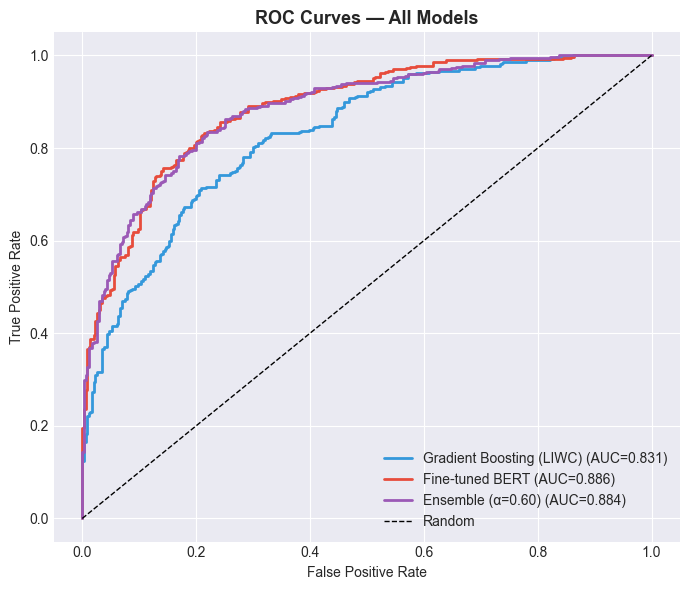

In [94]:
results = [
    {'Model': 'Gradient Boosting (LIWC)',       'F1': gb_f1,       'AUC': gb_auc},
    {'Model': 'Fine-tuned BERT',                 'F1': bert_f1,     'AUC': bert_auc},
    {'Model': f'Ensemble (α={best_alpha:.2f})',  'F1': ensemble_f1, 'AUC': ensemble_auc},
]
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['F1', 'AUC']):
    colors = ['#3498db', '#e74c3c', '#9b59b6']
    bars = ax.barh(results_df['Model'], results_df[metric], color=colors, edgecolor='black')
    ax.set_xlim(0.6, 1.0)
    ax.set_xlabel(metric, fontsize=12)
    ax.set_title(f'{metric} Score by Model', fontweight='bold', fontsize=13)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ── ROC curves ────────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 6))
for name, proba, color in [
    ('Gradient Boosting (LIWC)', gb_proba,       '#3498db'),
    ('Fine-tuned BERT',          bert_proba,     '#e74c3c'),
    (f'Ensemble (α={best_alpha:.2f})', ensemble_proba, '#9b59b6'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, linewidth=2, color=color, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontweight='bold', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


**Model comparison takeaways**:

- **BERT outperforms GBT** on both F1 and AUC, confirming that contextual language understanding captures the signals that the bag-of-features approach lacks.



## 8. Analysis #1: Subreddit-Specific Performance

**Question:** Are certain communities inherently easier to classify? Why?

**Why:** A model deployed in a triage system must be reliable *across all communities*, not just on average. Knowing where it struggles tells us where human oversight is most critical.

**Caveat:** Subreddits with fewer than 20 test samples produce unreliable F1 estimates and are flagged.


In [95]:
test_df = test_df.copy()
test_df['gb_pred']       = gb_pred
test_df['bert_pred']     = bert_pred
test_df['ensemble_pred'] = ensemble_pred
test_df['ensemble_prob'] = ensemble_proba

MIN_SAMPLES = 20   # flag subreddits below this as unreliable

sub_perf = []
for sub in test_df['subreddit'].unique():
    m      = test_df['subreddit'] == sub
    sub_df = test_df[m]
    n      = len(sub_df)
    try:
        sub_perf.append({
            'Subreddit':    sub,
            'N':            n,
            'Reliable':     n >= MIN_SAMPLES,
            'Stress Rate':  sub_df['label'].mean(),
            'GBT F1':       f1_score(sub_df['label'], sub_df['gb_pred']),
            'BERT F1':      f1_score(sub_df['label'], sub_df['bert_pred']),
            'Ensemble F1':  f1_score(sub_df['label'], sub_df['ensemble_pred']),
        })
    except Exception:
        pass

sub_df_stats = pd.DataFrame(sub_perf).sort_values('Ensemble F1', ascending=False)
print(sub_df_stats.round(3).to_string(index=False))
print()
unreliable = sub_df_stats[~sub_df_stats['Reliable']]['Subreddit'].tolist()
if unreliable:
    print(f"⚠ Low-sample subreddits (N < {MIN_SAMPLES}), treat with caution: {unreliable}")

plot_df = sub_df_stats[sub_df_stats['Reliable']].copy()

       Subreddit   N  Reliable  Stress Rate  GBT F1  BERT F1  Ensemble F1
     food_pantry   6     False        0.500   1.000    0.857        1.000
          stress  14     False        0.714   0.900    0.900        0.900
         anxiety 147      True        0.578   0.814    0.880        0.871
domesticviolence  72      True        0.653   0.821    0.860        0.851
            ptsd 127      True        0.646   0.810    0.867        0.847
      assistance  66      True        0.318   0.714    0.789        0.769
        homeless  52      True        0.346   0.703    0.750        0.769
  almosthomeless  19     False        0.632   0.727    0.762        0.762
survivorsofabuse  70      True        0.443   0.694    0.743        0.738
   relationships 142      True        0.423   0.661    0.699        0.705

⚠ Low-sample subreddits (N < 20), treat with caution: ['food_pantry', 'stress', 'almosthomeless']


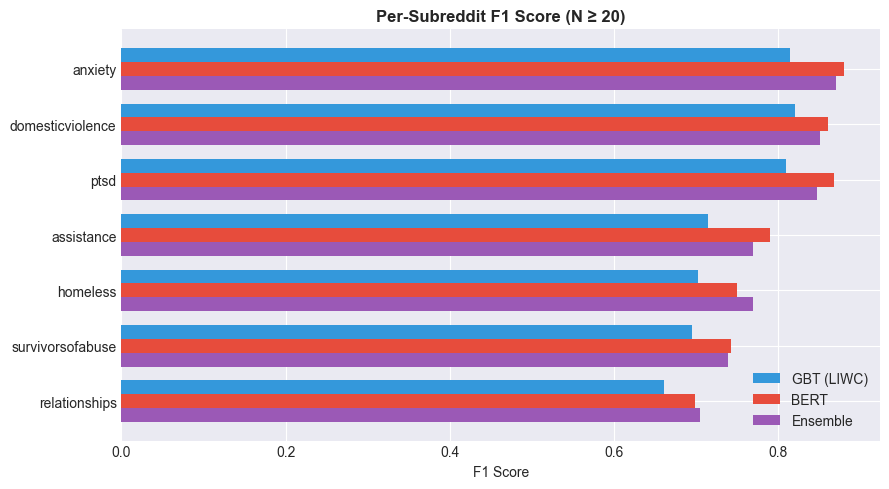

In [96]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(plot_df))
w = 0.25
ax.barh(x - w, plot_df['GBT F1'],      w, label='GBT (LIWC)',  color='#3498db')
ax.barh(x,     plot_df['BERT F1'],     w, label='BERT',        color='#e74c3c')
ax.barh(x + w, plot_df['Ensemble F1'], w, label='Ensemble',    color='#9b59b6')
ax.set_yticks(x)
ax.set_yticklabels(plot_df['Subreddit'])
ax.set_xlabel('F1 Score')
ax.set_title(f'Per-Subreddit F1 Score (N ≥ {MIN_SAMPLES})', fontweight='bold')
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.show()

**Interpretation:**

- Subreddits with fewer than 20 test samples (N < 20) are excluded from this analysis as they produce unreliable F1 estimates

- **r/anxiety, r/domesticviolence, and r/ptsd** perform best as these communities use explicit, consistent stress language, providing clear signals for both BERT and LIWC features.

- **r/relationships and r/homeless** are hardest to classify as posts here express stress more implicitly rather than directly.

- BERT  outperforms GBT across all subreddits

## 9. Analysis #2: Error Analysis

**Question:** When does the ensemble fail, and does it fail differently from GBT alone?

**Why:** In a triage system, **false negatives are more dangerous** (missing a distressed person) than false positives (over-flagging).

Error breakdown (Ensemble):
error
Correct           573
False Positive     83
False Negative     59
Name: count, dtype: int64



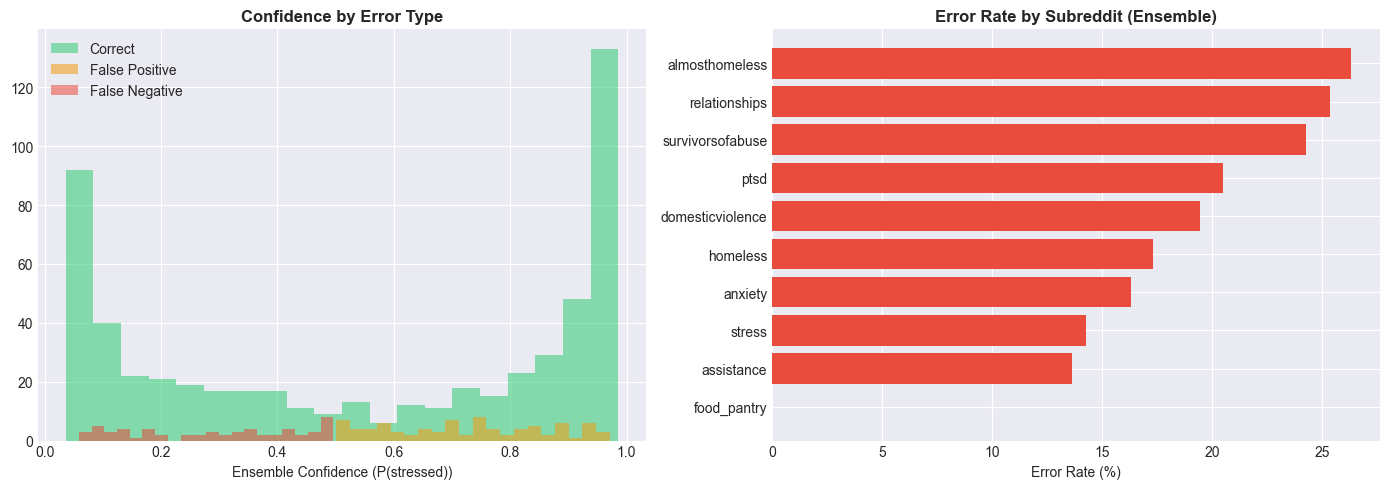

In [97]:
test_df['error'] = 'Correct'
test_df.loc[(test_df['label']==0)&(test_df['ensemble_pred']==1), 'error'] = 'False Positive'
test_df.loc[(test_df['label']==1)&(test_df['ensemble_pred']==0), 'error'] = 'False Negative'

print("Error breakdown (Ensemble):")
print(test_df['error'].value_counts())
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for etype, color in [('Correct','#2ecc71'), ('False Positive','#f39c12'), ('False Negative','#e74c3c')]:
    subset = test_df[test_df['error']==etype]['ensemble_prob']
    axes[0].hist(subset, bins=20, alpha=0.55, color=color, label=etype)
axes[0].set_xlabel('Ensemble Confidence (P(stressed))')
axes[0].set_title('Confidence by Error Type', fontweight='bold')
axes[0].legend()

sub_error = test_df.groupby('subreddit').apply(
    lambda x: (x['error'] != 'Correct').mean()
).sort_values(ascending=False)
axes[1].barh(sub_error.index, sub_error.values*100, color='#e74c3c')
axes[1].set_xlabel('Error Rate (%)')
axes[1].set_title('Error Rate by Subreddit (Ensemble)', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


In [98]:
CONF_THRESHOLD = 0.80
# Threshold Justification
# 0.80/0.20 was chosen to focus only on errors where the model was decisively wrong.

confident_fp = test_df[
    (test_df['error'] == 'False Positive') &
    (test_df['ensemble_prob'] >= CONF_THRESHOLD)
].sort_values('ensemble_prob', ascending=False)

confident_fn = test_df[
    (test_df['error'] == 'False Negative') &
    (test_df['ensemble_prob'] <= 1 - CONF_THRESHOLD)
].sort_values('ensemble_prob', ascending=True)

print(f"Confident False Positives  (ensemble confidence ≥ {CONF_THRESHOLD}): {len(confident_fp)}")
print(f"Confident False Negatives  (ensemble confidence ≤ {1-CONF_THRESHOLD}): {len(confident_fn)}")

print()
print("CONFIDENT FALSE POSITIVES — predicted stressed, actually not")
print()
for i, (_, row) in enumerate(confident_fp.head(3).iterrows()):
    print(f"\n[{i+1}] r/{row['subreddit']}  |  confidence={row['ensemble_prob']:.3f}")
    print(f"    {row['text'][:300]}...")

print()
print("CONFIDENT FALSE NEGATIVES — predicted not stressed, actually was")
print()
for i, (_, row) in enumerate(confident_fn.head(3).iterrows()):
    print(f"\n[{i+1}] r/{row['subreddit']}  |  confidence (non-stressed)={1 - row['ensemble_prob']:.3f}")
    print(f"    {row['text'][:300]}...")


Confident False Positives  (ensemble confidence ≥ 0.8): 28
Confident False Negatives  (ensemble confidence ≤ 0.19999999999999996): 21

CONFIDENT FALSE POSITIVES — predicted stressed, actually not


[1] r/relationships  |  confidence=0.971
    None of the issues we discuss get addressed. 6) After a while, I get really pissed, my significant other gets angry with me over some issue, and she ends up breaking up with me. I am weary of this whole emotional drama that I have to go through to end a relationship. I almost feel like it's not even...

[2] r/anxiety  |  confidence=0.951
    I’m  asking yall how can I live life properly? Immediately after I threw up  in year 2, I never feared it happening again. I admit when this happened  I was in tears, and same in year 3- I was crying next to my mum by the  toilet but it was over quick and again- I was eating chocolate again the  day...

[3] r/homeless  |  confidence=0.949
    Well, 18 years of being in and out of hospitals, treatment and addic

**Confident False Positives** (28 cases):
The model over-flags posts containing emotionally charged language such as text with conflict, anger, disappointmen. The examples from **r/relationships and r/survivorsofabuse** show that descriptions of past trauma can mimic stress signals strongly to signal the BERT and LIWC features.


**Confident False Negatives** (21 cases):
These are the more concerning errors. The model misses stress that is expressed indirectly, usually through storytelling, life updates, or gradual emotional decline rather than explicit distress language. The **r/ptsd** example is a clear example of this: the person describes losing all interest in hobbies and social withdrawal, which are strong clinical stress indicators but lack the direct emotional vocabulary the model relies on.


**Overall pattern**:
The model struggles with implicit stress where distress is embedded in context rather than expressed directly. This is a known limitation of both bag-of-words (LIWC) and fine-tuned language models when the writing style is descriptive rather than emotionally explicit.


## 11. Analysis #3: Model Disagreement Analysis

**Question:** When do BERT and GBT strongly disagree, and what does this reveal?

Ensemble performance depends on diversity between models (Kuncheva & Whitaker, 2003). When classifiers disagree, they may be capturing complementary patterns. High disagreement also signals uncertainty — a natural flag for human-in-the-loop validation.

We define high disagreement as |p_BERT − p_GBT| > 0.4.

**Reference:** Kuncheva, L. I., & Whitaker, C. J. (2003). Measures of diversity in classifier ensembles and their relationship with the ensemble accuracy. *Machine Learning, 51*(2), 181–207.


In [99]:
disagreement = np.abs(bert_proba - gb_proba)

test_df['gb_proba']       = gb_proba
test_df['bert_proba']     = bert_proba
test_df['ensemble_proba'] = ensemble_proba
test_df['disagreement']   = disagreement

print("=" * 70)
print("MODEL DISAGREEMENT ANALYSIS")
print("=" * 70)
print(f"\nDisagreement Statistics:")
print(f"  Mean disagreement:            {disagreement.mean():.3f}")
print(f"  Median disagreement:          {np.median(disagreement):.3f}")
print(f"  Max disagreement:             {disagreement.max():.3f}")
HIGH_DISAGREEMENT = 0.4
n_high = (disagreement > HIGH_DISAGREEMENT).sum()
print(f"  High disagreement (>0.4):     {n_high} cases ({n_high/len(disagreement)*100:.1f}%)")

high_dis = test_df[test_df['disagreement'] > HIGH_DISAGREEMENT].copy()

if len(high_dis) > 0:
    high_dis['pattern'] = 'other'
    high_dis.loc[(high_dis['bert_proba'] > 0.7) & (high_dis['gb_proba'] < 0.3), 'pattern'] = 'BERT stressed, GBT not'
    high_dis.loc[(high_dis['gb_proba'] > 0.7) & (high_dis['bert_proba'] < 0.3), 'pattern'] = 'GBT stressed, BERT not'

    print(f"\nHigh Disagreement Patterns:")
    print(high_dis['pattern'].value_counts())

    high_dis['bert_correct'] = (high_dis['bert_proba'] >= 0.5).astype(int) == high_dis['label']
    high_dis['gb_correct']   = (high_dis['gb_proba']   >= 0.5).astype(int) == high_dis['label']

    print(f"\nWhen models disagree (>0.4 difference):")
    print(f"  BERT correct: {high_dis['bert_correct'].sum()}/{len(high_dis)} ({high_dis['bert_correct'].mean()*100:.1f}%)")
    print(f"  GBT correct:  {high_dis['gb_correct'].sum()}/{len(high_dis)} ({high_dis['gb_correct'].mean()*100:.1f}%)")


MODEL DISAGREEMENT ANALYSIS

Disagreement Statistics:
  Mean disagreement:            0.175
  Median disagreement:          0.077
  Max disagreement:             0.898
  High disagreement (>0.4):     109 cases (15.2%)

High Disagreement Patterns:
pattern
other                     59
GBT stressed, BERT not    32
BERT stressed, GBT not    18
Name: count, dtype: int64

When models disagree (>0.4 difference):
  BERT correct: 75/109 (68.8%)
  GBT correct:  40/109 (36.7%)


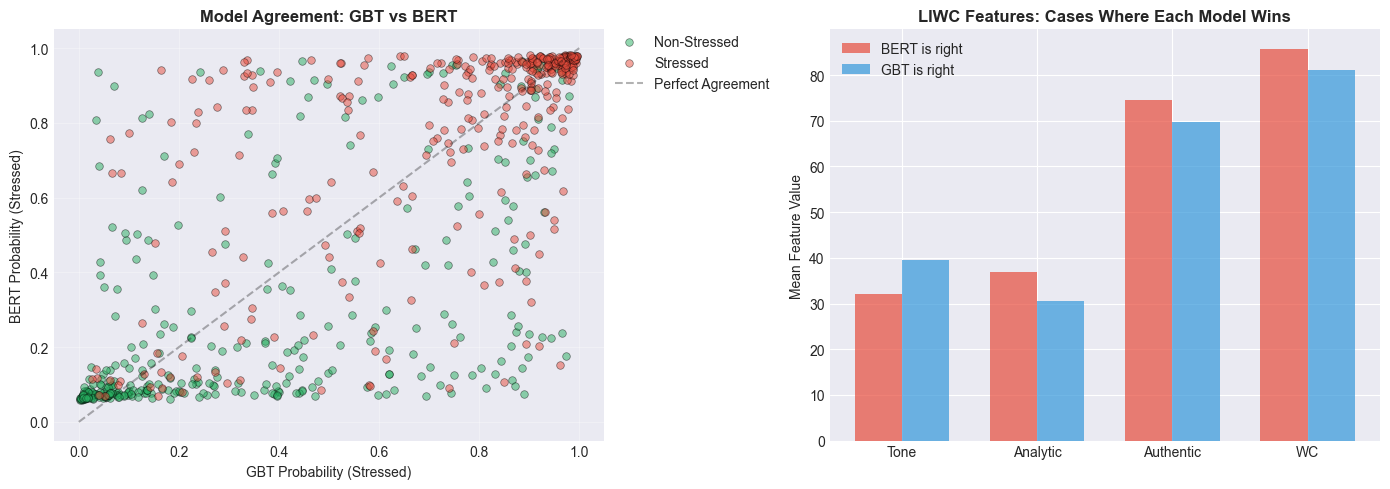

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scatter: GBT vs BERT probabilities
ax = axes[0]
stressed     = test_df[test_df['label'] == 1]
not_stressed = test_df[test_df['label'] == 0]
ax.scatter(not_stressed['gb_proba'], not_stressed['bert_proba'],
           alpha=0.5, s=30, c='#27ae60', label='Non-Stressed', edgecolors='k', linewidth=0.5)
ax.scatter(stressed['gb_proba'], stressed['bert_proba'],
           alpha=0.5, s=30, c='#e74c3c', label='Stressed', edgecolors='k', linewidth=0.5)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect Agreement')
ax.set_xlabel('GBT Probability (Stressed)')
ax.set_ylabel('BERT Probability (Stressed)')
ax.set_title('Model Agreement: GBT vs BERT', fontweight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0); ax.grid(alpha=0.3)


ax = axes[1]
if len(high_dis) > 10:
    bert_right = high_dis[high_dis['bert_correct'] & ~high_dis['gb_correct']]
    gb_right   = high_dis[~high_dis['bert_correct'] & high_dis['gb_correct']]
    if len(bert_right) > 0 and len(gb_right) > 0:
        # Finding the most distinguishing LIWC features
        liwc_cols    = [c for c in test_df.columns if 'liwc' in c]
        diffs        = abs(bert_right[liwc_cols].mean() - gb_right[liwc_cols].mean())
        key_features = diffs.nlargest(4).index.tolist()

        bert_means = [bert_right[f].mean() for f in key_features]
        gb_means   = [gb_right[f].mean()   for f in key_features]
        x = np.arange(len(key_features))
        w = 0.35
        ax.bar(x - w/2, bert_means, w, label='BERT is right', color='#e74c3c', alpha=0.7)
        ax.bar(x + w/2, gb_means,   w, label='GBT is right',  color='#3498db', alpha=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels([f.replace('lex_liwc_', '') for f in key_features])
        ax.set_ylabel('Mean Feature Value')
        ax.set_title('LIWC Features: Cases Where Each Model Wins', fontweight='bold')
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'Insufficient data\nfor this panel',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title('LIWC Features: Cases Where Each Model Wins', fontweight='bold')

plt.tight_layout()
plt.show()


**Scatter Plot**

The models agree most at the extremes — bottom-left (both confident non-stressed) and top-right (both confident stressed). The upper-left region is the most important: red dots where BERT assigns high stress probability but GBT does not — these are the implicit stress cases BERT is catching that GBT misses. The lower-right has fewer dots, meaning GBT rarely flags something as stressed that BERT completely dismisses.

**Bar Chart**

The 4 features with the biggest mean difference between BERT-is-right and GBT-is-right cases are Tone, Analytic, WC, and Authentic.
When BERT wins, Authenic, Analytic, and WC are all higher. This means that these posts are more structured and emotionally toned. 
When GBT wins, Tone is higher. This means that these posts are more personal and informal. 

**Overall** 

This suggests the two models are complementary. BERT handles structured, contextual posts while GBT handles more direct, personal expression hence justifying why the ensemble outperforms either model alone.


In [101]:
print("Examples of high disagreement")

patterns = {
    'BERT Says Stressed (>0.7), GBT Says Not (<0.3)': 'BERT stressed, GBT not',
    'GBT Says Stressed (>0.7), BERT Says Not (<0.3)': 'GBT stressed, BERT not',
}

if len(high_dis) > 0:
    for title, pattern in patterns.items():
        subset = high_dis[high_dis['pattern'] == pattern]
        if len(subset) == 0:
            continue
        print("\n" + "─" * 70)
        print(f"PATTERN: {title}")
        print("─" * 70)
        for _, row in subset.head(2).iterrows():
            label_str = 'Stressed' if row['label'] == 1 else 'Non-Stressed'
            print(f"\n  Subreddit: r/{row['subreddit']}  |  True label: {label_str}")
            print(f"  BERT: {row['bert_proba']:.3f} | GBT: {row['gb_proba']:.3f}")
            print(f"  Text: {row['text'][:300]}...")

Examples of high disagreement

──────────────────────────────────────────────────────────────────────
PATTERN: BERT Says Stressed (>0.7), GBT Says Not (<0.3)
──────────────────────────────────────────────────────────────────────

  Subreddit: r/ptsd  |  True label: Stressed
  BERT: 0.942 | GBT: 0.288
  Text: We'd be saving so much money with this new housr...its such an expensive city.... I did some googling in their language and found that it was illegal for them to do that. I was excited like oh ok if it happens ill call the police on them....  but now i did some further googling and turns out that if...

  Subreddit: r/relationships  |  True label: Stressed
  BERT: 0.801 | GBT: 0.235
  Text: I've been texting Rebecca on and off for the last week, always about my breakup. Bill went through Rebecca's phone last night and saw she was texting me. He lost his mind. He won't speak to her, and said I betrayed him. I tried to explain that he is my best friend and even if I liked Rebecca I w

## 12. Singapore Triage System

We can simulate a **three-tier triage system** for a platform like Let's Talk Singapore, where the model pre-filters posts for human counsellors.


         triage  Total  Truly_Stressed  Avg_Confidence  Precision  Pct_of_Total
  High Priority    286             248        0.910376       86.7          40.0
   Low Priority    213              24        0.112055       11.3          29.8
Medium Priority    216              97        0.500442       44.9          30.2


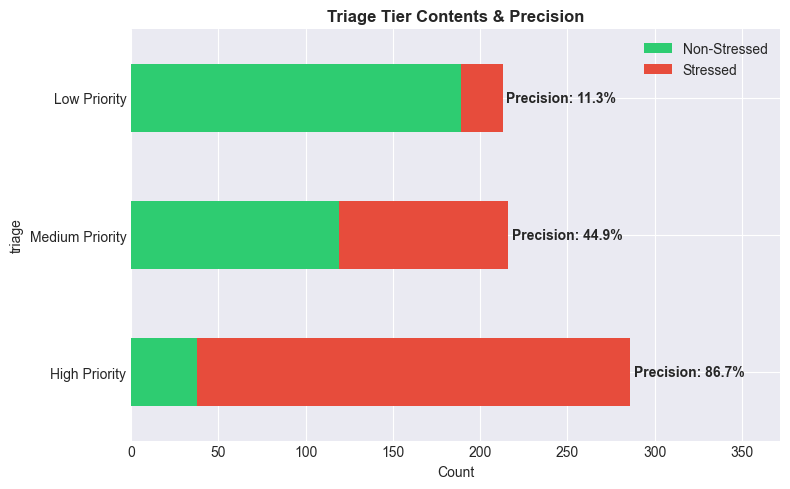

Of 369 truly stressed posts:
  Caught in High Priority:  248 (67.2%)
  Missed (Medium/Low):      121 (32.8%)

Human workload (High Priority tier): 286 posts = 40.0% of total


In [102]:
def triage(prob, high=0.75, low=0.25):
    # Setting thresholds of 0.75 and 0.25 create symmetric high-confidence regions around the 0.5 decision boundary.
    """Map ensemble probability to a triage priority."""
    if prob >= high:  return 'High Priority'
    if prob >= low:   return 'Medium Priority'
    return 'Low Priority'

test_df['triage'] = test_df['ensemble_prob'].apply(triage)

triage_stats = test_df.groupby('triage').agg(
    Total          = ('label', 'count'),
    Truly_Stressed = ('label', 'sum'),
    Avg_Confidence = ('ensemble_prob', 'mean')
).reset_index()
triage_stats['Precision']   = (triage_stats['Truly_Stressed'] / triage_stats['Total'] * 100).round(1)
triage_stats['Pct_of_Total'] = (triage_stats['Total'] / len(test_df) * 100).round(1)
print(triage_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))

triage_order = ['High Priority', 'Medium Priority', 'Low Priority']
triage_ct    = test_df.groupby(['triage', 'label']).size().unstack(fill_value=0).reindex(triage_order)
triage_ct.plot(kind='barh', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_xlabel('Count')
ax.set_title('Triage Tier Contents & Precision', fontweight='bold')
ax.legend(['Non-Stressed', 'Stressed'])

# Annotate precision on each bar
triage_stats_sorted = triage_stats.set_index('triage').reindex(triage_order)
for i, (tier, row) in enumerate(triage_stats_sorted.iterrows()):
    total_width = triage_ct.loc[tier].sum()
    ax.text(total_width + 2, i, f"Precision: {row['Precision']}%",
            va='center', fontweight='bold', fontsize=10)

ax.set_xlim(0, triage_ct.sum(axis=1).max() * 1.3)  # make room for annotations
plt.tight_layout()
plt.show()

high_priority  = test_df[test_df['triage'] == 'High Priority']
truly_stressed = test_df[test_df['label'] == 1]
caught         = high_priority[high_priority['label'] == 1]
print(f"Of {len(truly_stressed)} truly stressed posts:")
print(f"  Caught in High Priority:  {len(caught)} ({len(caught)/len(truly_stressed)*100:.1f}%)")
print(f"  Missed (Medium/Low):      {len(truly_stressed)-len(caught)} ({(len(truly_stressed)-len(caught))/len(truly_stressed)*100:.1f}%)")
print(f"\nHuman workload (High Priority tier): {len(high_priority)} posts = {len(high_priority)/len(test_df)*100:.1f}% of total")


**Triage Insights**

The triage system effectively separates posts by confidence. 

High Priority captures the majority of truly stressed posts with 86.7% precision, meaning when the model flags something urgent, it's right most of the time. 

Medium Priority is at 44.9%, representing ambiguous cases that require human review. 

Low Priority has 11.3% stress rate, meaning the model is confidently dismissing mostly non-stressed posts, though some stressed cases are inevitably missed here.

Overall, the system reduces urgent human workload to the High Priority tier while maintaining high confidence on flagged cases.

## 13. Conclusion

### Summary of findings


| Model | F1 (test) | AUC (test) | Strengths |
|-------|-----------|------------|-----------|
| Gradient Boosting (LIWC) | 0.7700 | 0.8312 | Interpretable, clinically grounded |
| Fine-tuned BERT | 0.8181 | 0.8864 | Contextual, handles nuance |
| Ensemble | 0.8136 | 0.8844 | Best overall, complementary strengths |

### What the model captures well
The ensemble reliably detects explicit emotional distress: direct anxiety/sadness language, self-focused rumination, low clout and agency, somatic complaints, and present-temporal narrowing. These align with decades of clinical psychology research on stress expression.

### Where it fails and why it matters
The model struggles with **understated chronic stress**, **indirect cultural expression**, and **factual narration of serious situations**. Critically, these failure modes are systematic. People who have normalised ongoing trauma are precisely the highest-risk group, and they're the ones the model misses.

### Real-world deployment in Singapore
A tool like this could support **Let's Talk** as a first-pass triage layer. The purpose is not to replace counsellors, but to help them prioritise when demand is high. Key requirements for safe deployment:

1. **Human-in-the-loop always**: No automated interventions.
2. **Retrain on local data**: Singaporean English, code-switching, and cultural norms differ from Western Reddit.
3. **Lower threshold for high-risk communities**: If a post is in a domestic violence or PTSD forum, flag it at lower confidence.
4. **Transparency**: Users should know AI is involved in triage.
5. **Audit for bias**: Ensure the model does not systematically miss stress from particular demographic groups.

### Final thought
The F1 score tells us the model is technically competent. The deeper analyses tell us it's clinically meaningful and clinically limited in specific, understandable ways. For mental health applications, knowing *where* and *why* a model fails is more important than the accuracy number.
